In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB

# Membuat Dataframe
data = {
    "C1": ["Murah", "Sedang", "Mahal", "Mahal", "Mahal", "Sedang", "Murah", "Murah", "Mahal", "Sedang"],
    "C2": ["Dekat", "Dekat", "Dekat", "Jauh", "Sedang", "Jauh", "Jauh", "Sedang", "Jauh", "Sedang"],
    "C3": ["Tidak", "Tidak", "Tidak", "Tidak", "Tidak", "Ada", "Ada", "Tidak", "Ada", "Ada"],
    "C4": ["Ya", "Ya", "Ya", "Tidak", "TIdak", "Tidak", "Tidak", "Ya", "Tidak", "Ya"]
}

df = pd.DataFrame(data)
print("=== Dataframe Awal ===")
print(df)

=== Dataframe Awal ===
       C1      C2     C3     C4
0   Murah   Dekat  Tidak     Ya
1  Sedang   Dekat  Tidak     Ya
2   Mahal   Dekat  Tidak     Ya
3   Mahal    Jauh  Tidak  Tidak
4   Mahal  Sedang  Tidak  TIdak
5  Sedang    Jauh    Ada  Tidak
6   Murah    Jauh    Ada  Tidak
7   Murah  Sedang  Tidak     Ya
8   Mahal    Jauh    Ada  Tidak
9  Sedang  Sedang    Ada     Ya


In [2]:
# Encoding Label

encoders = {col: LabelEncoder() for col in df.columns}

for col in df.columns:
    df[col + "_enc"] = encoders[col].fit_transform(df[col])

print("=== Dataframe Setelah Encoding ===")
print(df)

=== Dataframe Setelah Encoding ===
       C1      C2     C3     C4  C1_enc  C2_enc  C3_enc  C4_enc
0   Murah   Dekat  Tidak     Ya       1       0       1       2
1  Sedang   Dekat  Tidak     Ya       2       0       1       2
2   Mahal   Dekat  Tidak     Ya       0       0       1       2
3   Mahal    Jauh  Tidak  Tidak       0       1       1       1
4   Mahal  Sedang  Tidak  TIdak       0       2       1       0
5  Sedang    Jauh    Ada  Tidak       2       1       0       1
6   Murah    Jauh    Ada  Tidak       1       1       0       1
7   Murah  Sedang  Tidak     Ya       1       2       1       2
8   Mahal    Jauh    Ada  Tidak       0       1       0       1
9  Sedang  Sedang    Ada     Ya       2       2       0       2


In [3]:
# Data Training
X = df[["C1_enc", "C2_enc", "C3_enc"]]
y = df["C4_enc"]

# Membuat dan Melatih Model Naive Bayes Kategorikal
model = CategoricalNB()
model.fit(X, y)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [7]:
# Data Testing
sample = [[
    encoders["C1"].transform(["Mahal"])[0],
    encoders["C2"].transform(["Sedang"])[0],
    encoders["C3"].transform(["Ada"])[0],
]]

probabilities = model.predict_proba(sample)[0]
prediction = model.predict(sample)[0]
predicted_label = encoders["C4"].inverse_transform([prediction])[0]

print("=== Hasil Prediksi ===")
print("Probabbilitas Tidak dipilih:", probabilities[0])
print("Probabilitas dipilih:", probabilities[1])
print("Kesimpulan Prediksi:", predicted_label)

=== Hasil Prediksi ===
Probabbilitas Tidak dipilih: 0.21899441340782114
Probabilitas dipilih: 0.42905027932960893
Kesimpulan Prediksi: Tidak


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


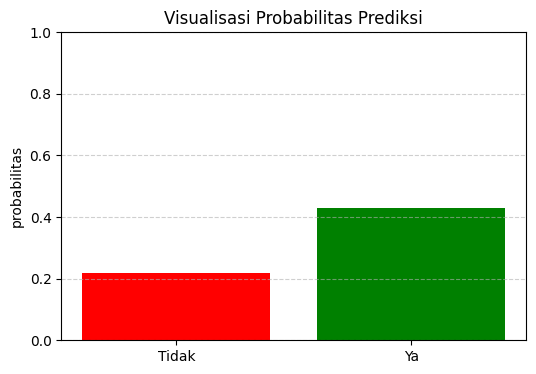

In [5]:
# Visualisasi Probabilitas
import matplotlib.pyplot as plt

# Probabillitas hasil prediksi naive bayes
prob_tidak = probabilities[0]
prob_ya = probabilities[1]

labels = ["Tidak", "Ya"]
values = [prob_tidak, prob_ya]

# Membuat bar chart dgn warna khusus dan grid
plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['red', 'green'])

plt.title("Visualisasi Probabilitas Prediksi")
plt.ylabel("probabilitas")
plt.ylim(0, 1)

# Menambahkan grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


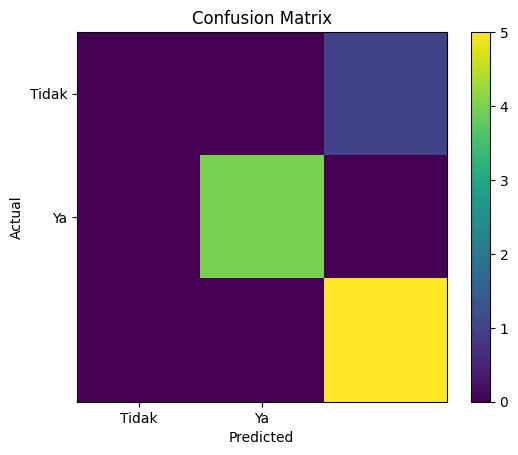

[[0 0 1]
 [0 4 0]
 [0 0 5]]


In [6]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)

plt.Figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0, 1], ["Tidak", "Ya"])
plt.yticks([0, 1], ["Tidak", "Ya"])
plt.show()

print(cm)